In [44]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
#save_directory = "./saved_models/gemma3"
save_directory = "./saved_models/lfm2-350M"
tokenizer = AutoTokenizer.from_pretrained(save_directory)
model = AutoModelForCausalLM.from_pretrained(
    save_directory,
    dtype=torch.bfloat16,
    device_map="cuda:0"
)

model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Lfm2ForCausalLM(
  (model): Lfm2Model(
    (embed_tokens): Embedding(65536, 1024, padding_idx=0)
    (layers): ModuleList(
      (0-1): 2 x Lfm2DecoderLayer(
        (conv): Lfm2ShortConv(
          (conv): Conv1d(1024, 1024, kernel_size=(3,), stride=(1,), padding=(2,), groups=1024, bias=False)
          (in_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (out_proj): Linear(in_features=1024, out_features=1024, bias=False)
        )
        (feed_forward): Lfm2MLP(
          (w1): Linear(in_features=1024, out_features=4608, bias=False)
          (w3): Linear(in_features=1024, out_features=4608, bias=False)
          (w2): Linear(in_features=4608, out_features=1024, bias=False)
        )
        (operator_norm): Lfm2RMSNorm((1024,), eps=1e-05)
        (ffn_norm): Lfm2RMSNorm((1024,), eps=1e-05)
      )
      (2): Lfm2DecoderLayer(
        (self_attn): Lfm2Attention(
          (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (k_proj): Li

In [48]:
device = 'cuda:0'
layer = model.model.layers[2]
layer

Lfm2DecoderLayer(
  (self_attn): Lfm2Attention(
    (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (k_proj): Linear(in_features=1024, out_features=512, bias=False)
    (v_proj): Linear(in_features=1024, out_features=512, bias=False)
    (out_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (q_layernorm): Lfm2RMSNorm((64,), eps=1e-05)
    (k_layernorm): Lfm2RMSNorm((64,), eps=1e-05)
  )
  (feed_forward): Lfm2MLP(
    (w1): Linear(in_features=1024, out_features=4608, bias=False)
    (w3): Linear(in_features=1024, out_features=4608, bias=False)
    (w2): Linear(in_features=4608, out_features=1024, bias=False)
  )
  (operator_norm): Lfm2RMSNorm((1024,), eps=1e-05)
  (ffn_norm): Lfm2RMSNorm((1024,), eps=1e-05)
)

In [49]:
input_text = "I love football!"
inputs = tokenizer(input_text, return_tensors='pt').to(device)
gen = inputs.input_ids
for i in range(50):
    with torch.no_grad():
        out = model(gen)
    if i==0:
        print(f"The shape of the logits: {out.logits.shape}")
    next_token_logits = out.logits[:, -1, :] # last token
    next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
    gen = torch.cat([gen, next_token], dim=-1)
print(tokenizer.decode(gen[0], skip_special_tokens=True))

The shape of the logits: torch.Size([1, 5, 65536])
I love football! I've seen some amazing matches and played in some of the best teams. There's something about the way a team can come together and create a beautiful game that's hard to put down.

I've also got a bit of a passion for the


In [50]:
input_text = "I love football!"
inputs = tokenizer(input_text, return_tensors='pt').to(device)
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=50,
    )

print(tokenizer.decode(output_ids[0], skip_special_tokens=True))

I love football! I've seen some amazing matches and played in some of the best teams. There's something about the way a team can come together and create a beautiful game that's hard to put down.

I've also got a bit of a passion for the


In [51]:
input_text = "I love football!"
inputs = tokenizer(input_text, return_tensors='pt').to(device)
# shape: (batch, seq_len, out_feats)
k_outputs = {}
q_outputs = {}
v_outputs = {}

def save_q(name):
    def hook(module, input, output):
        q_outputs[name] = output.detach().cpu()

    return hook

def save_k(name):
    def hook(module, input, output):
        k_outputs[name] = output.detach().cpu()

    return hook

def save_v(name):
    def hook(module, input, output):
        v_outputs[name] = output.detach().cpu()

    return hook

layer0 = model.model.layers[2]
q_handle = layer0.self_attn.q_proj.register_forward_hook(save_q("layer0_q"))
k_handle = layer0.self_attn.k_proj.register_forward_hook(save_k("layer0_k"))
v_handle = layer0.self_attn.v_proj.register_forward_hook(save_v("layer0_v"))

with torch.no_grad():
    _ = model(**inputs)

print(q_outputs["layer0_q"].shape)
print(k_outputs["layer0_k"].shape)
print(v_outputs["layer0_v"].shape)
q_outputs["layer0_q"]

torch.Size([1, 5, 1024])
torch.Size([1, 5, 512])
torch.Size([1, 5, 512])


tensor([[[-0.0020, -0.0047,  0.0095,  ..., -0.0212, -0.0101,  0.0067],
         [ 0.0083,  0.0062, -0.0021,  ..., -0.0140,  0.0233,  0.0084],
         [ 0.0117,  0.0144,  0.0092,  ...,  0.0221,  0.0111,  0.0041],
         [ 0.0112, -0.0054,  0.0059,  ..., -0.0106, -0.0029,  0.0095],
         [ 0.0157,  0.0132, -0.0085,  ...,  0.0044,  0.0273, -0.0258]]],
       dtype=torch.bfloat16)

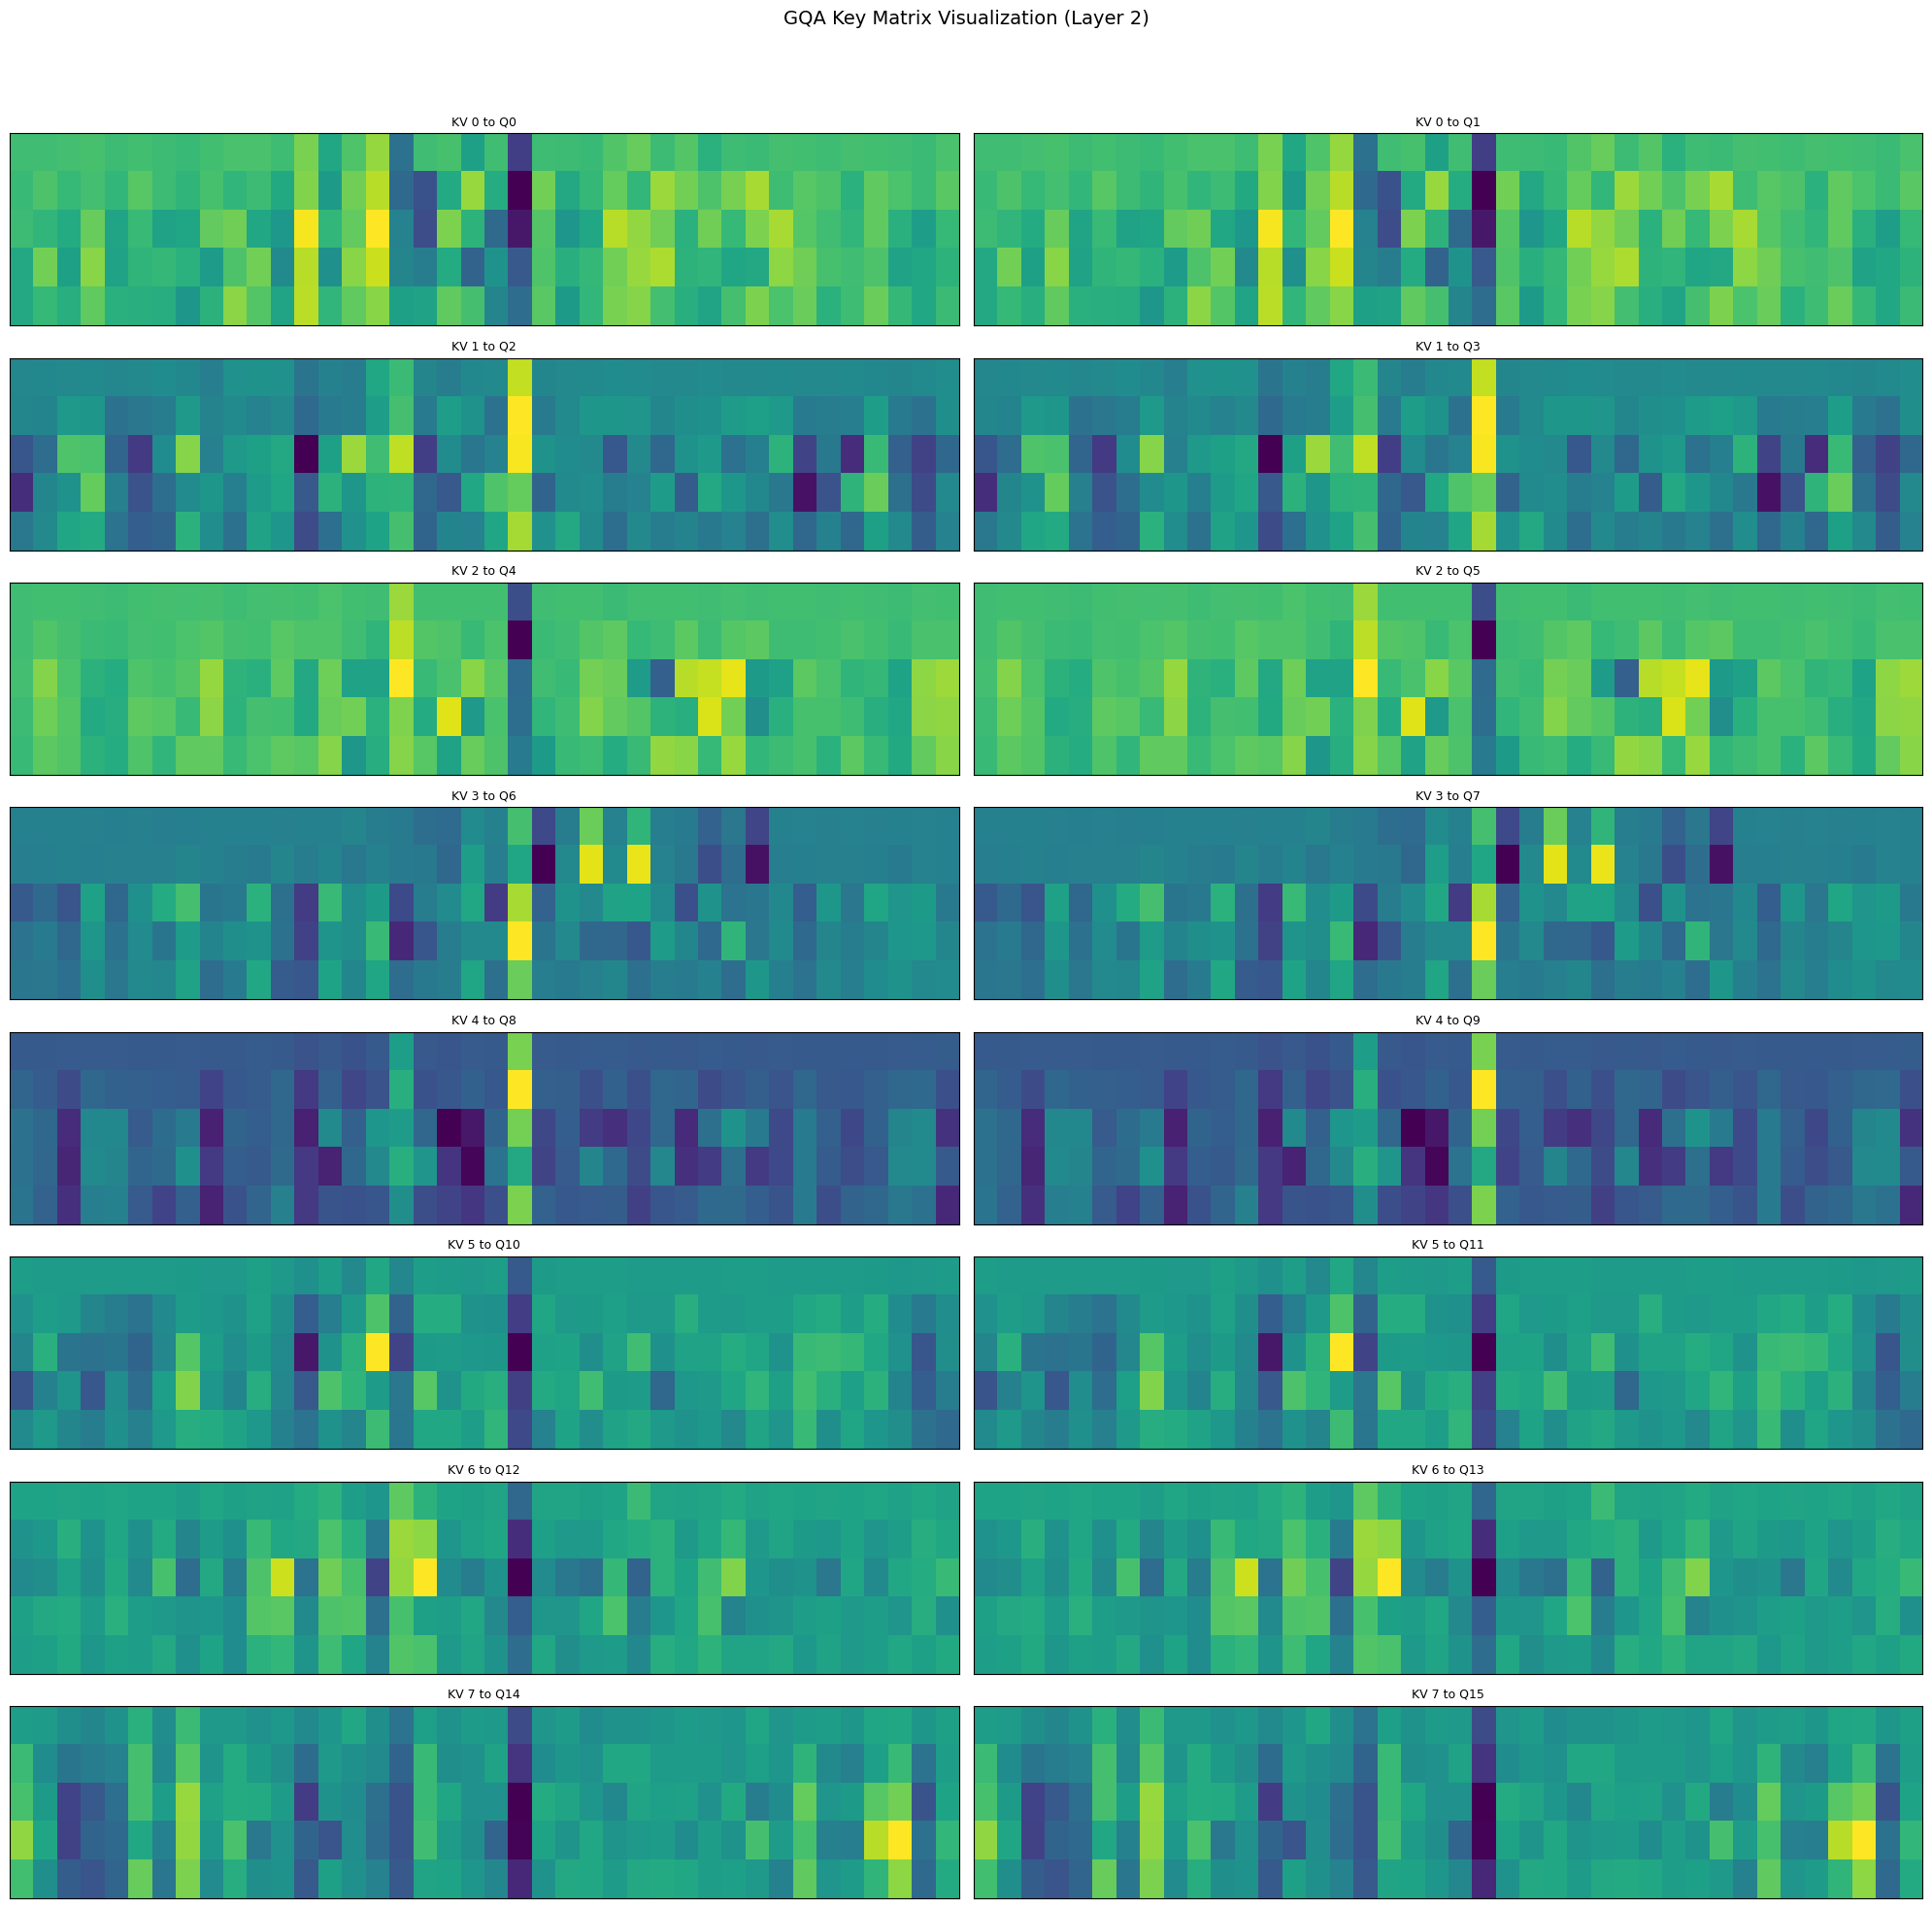

In [62]:
import matplotlib.pyplot as plt

num_q_heads = model.config.num_attention_heads
num_kv_heads = model.config.num_key_value_heads
hidden_size = model.config.hidden_size
head_dim = hidden_size // num_q_heads

q = q_outputs["layer0_q"].float()   # (B, T, hidden)
k = k_outputs["layer0_k"].float()
v = v_outputs["layer0_v"].float()

B, T, _ = k.shape

# Q: (B, T, num_q_heads, head_dim)
q = q.view(B, T, num_q_heads, head_dim)

# K/V: (B, T, num_kv_heads, head_dim)
k = k.view(B, T, num_kv_heads, head_dim)
v = v.view(B, T, num_kv_heads, head_dim)

# Move head dimension forward for easier indexing
# K -> (B, num_kv_heads, T, head_dim)
k_heads = k.permute(0, 2, 1, 3)

# Build GQA mapping
group_size = num_q_heads // num_kv_heads
q_to_kv = {q_head: q_head // group_size for q_head in range(num_q_heads)}

kv_groups = {}
for q_head, kv_head in q_to_kv.items():
    kv_groups.setdefault(kv_head, []).append(q_head)

plt.figure(figsize=(20, 2.5 * len(kv_groups)))

for row_idx, (kv_id, q_heads) in enumerate(kv_groups.items()):
    for i, q_head in enumerate(q_heads):

        # Extract first token, first 40 dims (change if needed)
        #key_matrix = k_heads[0, kv_id, 0:1, :40]
        key_matrix = k_heads[0, kv_id, :, :40]

        subplot_index = row_idx * len(q_heads) + i + 1
        plt.subplot(len(kv_groups), len(q_heads), subplot_index)

        plt.imshow(key_matrix.numpy(), aspect='auto')
        plt.title(f"KV {kv_id} to Q{q_head}", fontsize=9)
        plt.xticks([])
        plt.yticks([])

plt.suptitle("GQA Key Matrix Visualization (Layer 2)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()